In [1]:
import numpy as np
import xarray as xr
import os
import matplotlib.pyplot as plt

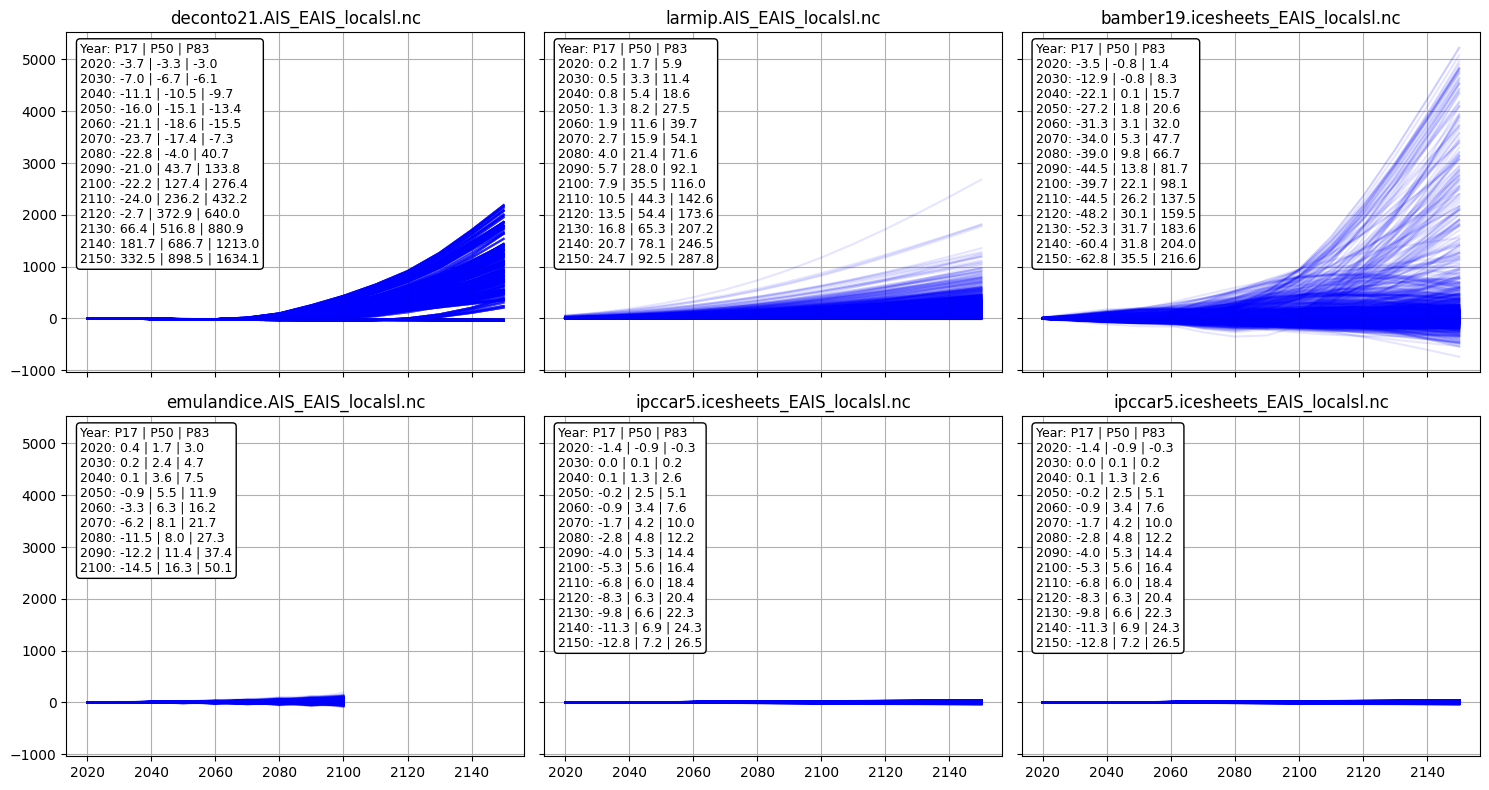

In [2]:
# List of your 6 NetCDF files
filepaths = [
    "coupling.ssp585.deconto21.deconto21.AIS_EAIS_localsl.nc", 
    "coupling.ssp585.larmip.larmip.AIS_EAIS_localsl.nc", 
    "coupling.ssp585.bamber19.bamber19.icesheets_EAIS_localsl.nc",
    "coupling.ssp585.emuAIS.emulandice.AIS_EAIS_localsl.nc", 
    "coupling.ssp585.ar5AIS.ipccar5.icesheets_EAIS_localsl.nc", 
    "coupling.ssp585.ar5AIS.ipccar5.icesheets_EAIS_localsl.nc"
]

filepaths = [f"data4mJason/{fp}" for fp in filepaths]

# Set up 2x3 grid of plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten for easy indexing

for i, filepath in enumerate(filepaths):
    # print(filepath)
    ds = xr.open_dataset(filepath)
    da = ds['sea_level_change'].isel(locations=0)

    # Plot all samples for this dataset
    axes[i].plot(ds['years'], da.T, color='blue', alpha=0.1)

    # Compute percentiles across samples, for each year
    p17 = np.percentile(da, 17, axis=0)
    p50 = np.percentile(da, 50, axis=0)
    p83 = np.percentile(da, 83, axis=0)

    years = ds['years'].values

    # Build multiline string showing all years + percentile values
    lines = [f"{int(y)}: {p17[j]:.1f} | {p50[j]:.1f} | {p83[j]:.1f}" 
             for j, y in enumerate(years)]
    textstr = "Year: P17 | P50 | P83\n" + "\n".join(lines)

    # Add text box inside subplot
    axes[i].text(
        0.03, 0.97, textstr,
        transform=axes[i].transAxes,
        fontsize=9,
        verticalalignment='top',
        horizontalalignment='left',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
    )

    axes[i].set_title(".".join(filepath.split('/')[-1].split('.')[3:]))
    # axes[i].set_xlabel("Year")
    # axes[i].set_ylabel("Sea Level Change")
    axes[i].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()
